## Notebook to reproduce Fig 6

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ["MKL_NUM_THREADS"] = '1'
os.environ["VECLIB_MAXIMUM_THREADS"] = '1'
os.environ["NUMEXPR_NUM_THREADS"] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['NPROC'] = '1'

import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from glob import glob
import h5py

In [2]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 10,
    'figure.figsize': (4, 4),
    'figure.titlesize': 'large',
    'axes.titlesize': 'large',
    'axes.labelsize': 'large',
    'xtick.top': True,
    'xtick.major.size': 2,
    'xtick.minor.size': 1,
    'xtick.minor.visible': True,
    'xtick.direction': 'out',
    'xtick.labelsize': 'medium',
    'ytick.right': True,
    'ytick.major.size': 2,
    'ytick.minor.size': 1,
    'ytick.minor.visible': True,
    'ytick.direction': 'out',
    'ytick.labelsize': 'medium',
    'legend.frameon': True,
    'legend.framealpha': 1,
    'legend.fontsize': 'medium',
    'lines.linewidth': 1,
    })

In [5]:
#load posterior samples

file = (
    '../Results/'
    'posterior_samples.h5'
)

In [6]:
def load_pe(key):
    with h5py.File(file, 'r') as f:
        samples = f[key]['posterior_samples'][:]
    return {k: samples[k] for k in ('mass_1_source', 'mass_2_source')}

## putative gap probabilities

In [7]:
pe = load_pe('C00:Mixed')

In [8]:
lower = 60
upper = 130

In [9]:
# primary in gap
(1
    * (pe['mass_1_source'] > lower) * (pe['mass_1_source'] < upper)
).mean()

0.2605392760403841

In [10]:
# secondary in gap
(1
    * (pe['mass_2_source'] > lower) * (pe['mass_2_source'] < upper)
).mean()

0.8297956168431421

In [11]:
# primary above gap
(pe['mass_1_source'] > upper).mean()

0.7394607239596158

In [12]:
# secondary above gap
(pe['mass_2_source'] > upper).mean()

0.012250677173110071

In [13]:
# primary below gap
(pe['mass_1_source'] < lower).mean()

0.0

In [14]:
# secondary below gap
(pe['mass_2_source'] < lower).mean()

0.15795370598374783

In [15]:
# primary in gap, secondary in gap
(1
    * (pe['mass_1_source'] > lower) * (pe['mass_1_source'] < upper)
    * (pe['mass_2_source'] > lower) * (pe['mass_2_source'] < upper)
).mean()

0.24759911351883773

In [16]:
# primary above gap, secondary in gap
(1
    * (pe['mass_1_source'] > upper)
    * (pe['mass_2_source'] > lower) * (pe['mass_2_source'] < upper)
).mean()

0.5821965033243044

In [17]:
# primary in gap, secondary below gap
(1
    * (pe['mass_1_source'] > lower) * (pe['mass_1_source'] < upper)
    * (pe['mass_2_source'] < lower)
).mean()

0.012940162521546417

In [18]:
# primary above gap, secondary below gap
(1
    * (pe['mass_1_source'] > upper)
    * (pe['mass_2_source'] < lower)
).mean()

0.14501354346220144

In [19]:
# primary above gap, secondary above gap
(1
    * (pe['mass_1_source'] > upper)
    * (pe['mass_2_source'] > upper)
).mean()

0.012250677173110071

In [20]:
# primary below gap, secondary below gap
(1
    * (pe['mass_1_source'] < lower)
    * (pe['mass_2_source'] < lower)
).mean()

0.0

## varying gap plot

In [21]:
def plot_probs(key = 'C00:Mixed', unity = False, width = False, lines = []):
    pe = load_pe(key)

    lo = np.linspace(40, 100, 100)
    if width:
        w = np.linspace(50, 100, 100)
        # add last axis to broadcast with PE samples
        grid = np.array(np.meshgrid(lo, w, indexing = 'ij'))[..., None]
        lower, upper = grid[0], grid[0] + grid[1]
    else:
        hi = np.linspace(120, 180, 100)
        lower, upper = np.array(np.meshgrid(lo, hi, indexing = 'ij'))[..., None]

    in1 = (lower < pe['mass_1_source']) * (pe['mass_1_source'] < upper)
    in2 = (lower < pe['mass_2_source']) * (pe['mass_2_source'] < upper)
    above1 = pe['mass_1_source'] > upper
    above2 = pe['mass_2_source'] > upper
    below2 = pe['mass_2_source'] < lower

    # probs = np.mean([in1 * in2, above1 * in2, above1 * below2, above1 * above2], axis = -1)
    probs = np.mean([in1 * in2, above1 * in2, in1 * below2, above1 * below2], axis = -1)

    if width:
        extent = lo.min(), lo.max(), w.min(), w.max()
        yticks = np.arange(w.min(), x.max() + 1, 10)
        ylabel = 'Gap width [$M_\odot$]'
    else:
        extent = lo.min(), lo.max(), hi.min(), hi.max()
        yticks = np.arange(hi.min(), hi.max() + 1, 10)
        ylabel = 'Upper edge [$M_\odot$]'

    fig, axs = plt.subplots(
        nrows = 2, ncols = 3, figsize = (5, 4.5), sharex = True, sharey = True,
        gridspec_kw = dict(wspace = 0.2, hspace = 0.2, width_ratios = (1, 1, 0.1)),
    )
    gs = axs[0, -1].get_gridspec()
    cax = axs[:, -1]
    for ax in cax:
        ax.remove()
    cax = fig.add_subplot(gs[:, -1])
    axs = axs[:, :-1].ravel()

    for i, p in enumerate(probs):
        im = axs[i].imshow(
            p.T,
            # np.log10(z.mean(axis = -1).T),
            origin = 'lower',
            extent = extent,
            vmin = 0, # probs.min(),
            vmax = 1 if unity else probs.max(),
            aspect = 'equal',
            # cmap = 'plasma',
        )

    fig.colorbar(im, cax = cax, label = 'Probability', ticks = np.linspace(0, 1, 11))

    if not width:
        x = np.linspace(lo.min(), lo.max(), 10_000)
        for ax in axs:
            for fixed_width in lines:
                y = x + fixed_width
                ax.plot(x, y, c = 'w', ls = '--', lw = 1)

                cut = (lo.min() < x) * (x < lo.max()) * (hi.min() < y) * (y < hi.max())
                xlo = x[cut].min()
                xhi = x[cut].max()
                xx = (xlo + xhi) / 2
                ylo = y[cut].min()
                yhi = y[cut].max()
                yy = (ylo + yhi) / 2
                ax.text(
                    xx, yy + 4, f'{fixed_width}$M_\odot$',
                    ha = 'center', va = 'center', c = 'w', rotation = 45,
                )

            ax.set_ylim(hi.min(), hi.max())

    for ax in axs:
        ax.set_xticks(np.arange(lo.min(), lo.max() + 1, 10))
        ax.set_yticks(yticks)

    for ax in axs[2], axs[3]:
        ax.set_xlabel('Lower edge [$M_\odot$]')

    for ax in axs[0], axs[2]:
        ax.set_ylabel(ylabel)

    axs[0].set_title('$m_1$ in, $m_2$ in')
    axs[1].set_title('$m_1$ above, $m_2$ in')
    axs[2].set_title('$m_1$ in, $m_2$ below')
    axs[3].set_title('$m_1$ above, $m_2$ below')

    return fig, probs, lower.squeeze(), upper.squeeze()

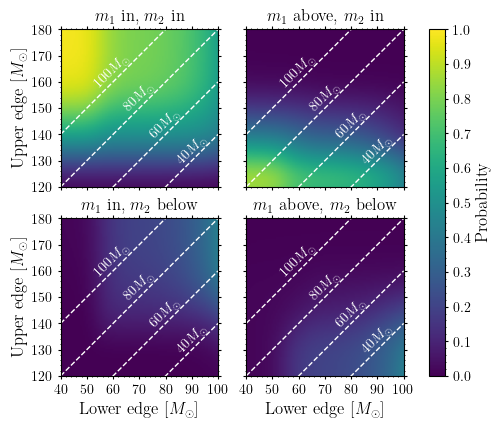

In [25]:
fig, probs, lower, upper = plot_probs(
    key = 'C00:Mixed', unity = True, width = False, lines = [40, 60, 80, 100],
)
fig.savefig('../Figures/gap-probability.pdf', bbox_inches = 'tight')